### Imports

In [1]:

import warnings

import torch

from src.config import CONFIG
from src.run_train import train_and_benchmark
from src.types.dataset_type import DatasetType
from src.types.filterbank_type import FilterbankType
from src.types.model_type import ModelType
from src.utils.hyperparameter_sweep_utils import run_hyperparameter_sweep
from src.utils.plotting_utils import plot_training_history

warnings.filterwarnings("ignore", category=UserWarning)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
MODEL = ModelType.SNN_DIRECT
DATASET = DatasetType.AUDIOMNIST
FILTERBANK = FilterbankType.MEL

### Device

In [3]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Using device: {device}')

Using device: mps


### Hyperparameter Tuning

In [4]:
if CONFIG.hyperparameter_tuning.should_run:
    run_hyperparameter_sweep(device, MODEL, DATASET, FILTERBANK)

### Training

Hyperparameters used: {'lr': 0.002166218735424637, 'model_init': {'beta_init': 0.5891520415207885, 'slope': 30, 'timesteps': 5}}

Training SNN_DIRECT...
[Epoch 1/5]


Validation: 100%|██████████| 12/12 [00:07<00:00,  1.58batches/s]


Train Loss: 1.42 | Train Accuracy: 55.30% | Val Loss: 0.71 | Val Accuracy: 81.77%

[Epoch 2/5]


Validation: 100%|██████████| 12/12 [00:02<00:00,  5.60batches/s]


Train Loss: 0.55 | Train Accuracy: 85.35% | Val Loss: 0.36 | Val Accuracy: 90.73%

[Epoch 3/5]


...

Train Loss: 0.20 | Train Accuracy: 96.66% | Val Loss: 0.19 | Val Accuracy: 96.87%

[Epoch 5/5]


Validation: 100%|██████████| 12/12 [00:02<00:00,  4.08batches/s]


Train Loss: 0.17 | Train Accuracy: 97.25% | Val Loss: 0.17 | Val Accuracy: 97.30%

Best model had an accuracy of 97.30%.
Running final test...


Testing: 100%|██████████| 12/12 [00:08<00:00,  1.42batches/s]


Test Accuracy: 97.77% | Total MACs: 1,380,000 | Total ACs: 1,072,396


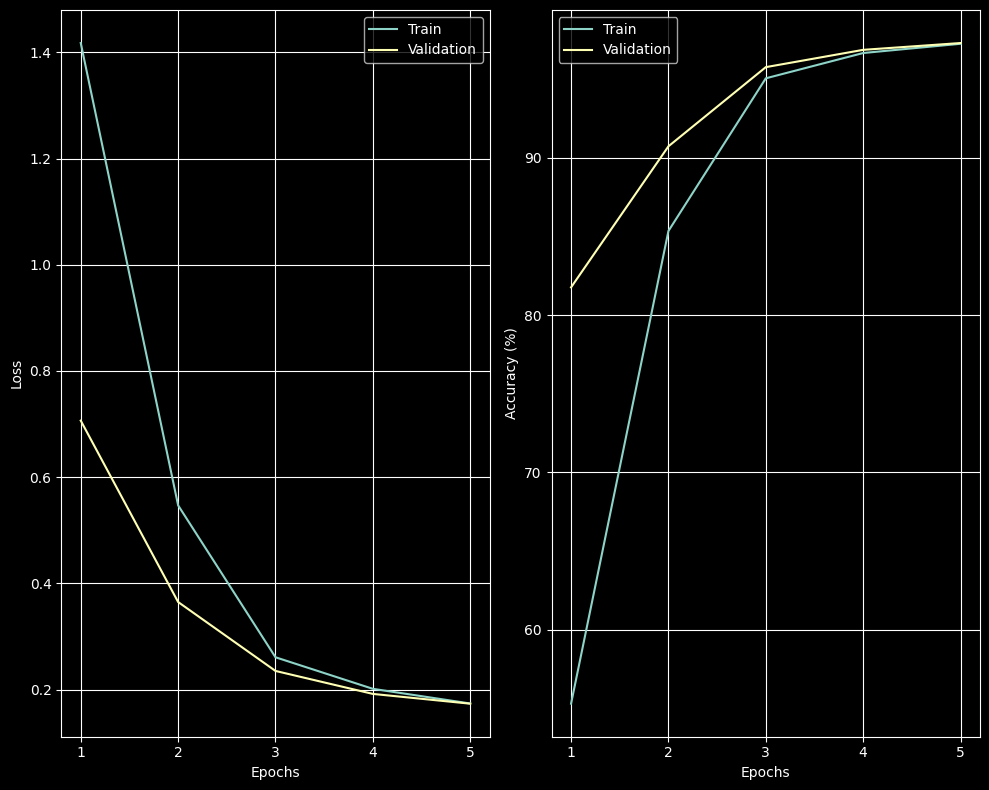

In [5]:
results = train_and_benchmark(device, MODEL, DATASET, FILTERBANK)
plot_training_history(**results['epoch_history'])